In [1]:
 # !pip install -U torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
# # Install Pytorch & other libraries
# %pip install "torch>=2.4.0" tensorboard torchvision

# # Install Gemma release branch from Hugging Face
# %pip install "transformers>=4.51.3"

# # Install Hugging Face libraries
# %pip install  --upgrade \
#   "datasets==3.3.2" \
#   "accelerate==1.4.0" \
#   "evaluate==0.4.3" \
#   "bitsandbytes==0.45.3" \
#   "trl==0.15.2" \
#   "peft==0.14.0" \
#   "pillow==11.1.0" \
#   protobuf \
#   sentencepiece

In [4]:
import os

# List input directory contents
os.listdir("/kaggle/input")


['balanced-longitudinal-balanced',
 'train-formatted',
 'optimal-carving-475915-u7-4c85df30bf2f',
 'eval-formatted']

In [5]:
#  Set your credentials
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] ="/kaggle/input/optimal-carving-475915-u7-4c85df30bf2f/optimal-carving-475915-u7-4c85df30bf2f.json"

#  Initialize the client with your project
project_id = "bernices-ai-project"  
client = storage.Client(project=project_id)

In [6]:
# Initialise the GCS client
client = storage.Client()

# Bucket name
bucket_name = "bernices-xray-dataset"  

# Get the bucket
bucket = client.bucket(bucket_name)


In [7]:
blob = bucket.blob("PNG/train/patient00007/study1/view1_frontal.png")
image_bytes = blob.download_as_bytes()
image = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)

print(" Image loaded successfully from private GCS bucket")
print("Image shape:", image.shape)

 Image loaded successfully from private GCS bucket
Image shape: (2320, 2828, 3)


In [13]:
csv_path= "/kaggle/input/balanced-longitudinal-balanced/balanced_longitudinal_balanced.csv"

In [15]:
df= pd.read_csv(csv_path)

In [10]:
import pandas as pd
import os
from google.cloud import storage
import cv2
import numpy as np

import gcsfs
from PIL import Image
from io import BytesIO
from IPython.display import display
from peft import LoraConfig, get_peft_model
from transformers import  AutoProcessor, BitsAndBytesConfig
import torch
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
import gc
from huggingface_hub import login
import torch
from transformers import AutoProcessor, AutoModelForVision2Seq

2025-11-15 08:20:44.046717: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763194844.516489     139 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763194844.617719     139 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [16]:
df.columns

Index(['patient_id', 'prior_image_path', 'prior_report', 'prior_study_order',
       'prior_age', 'prior_frontal_lateral', 'prior_ap_pa',
       'prior_section_findings', 'prior_section_impression',
       'prior_recent_bmi', 'current_image_path', 'current_report',
       'current_study_order', 'current_age', 'current_frontal_lateral',
       'current_ap_pa', 'current_section_findings',
       'current_section_impression', 'current_recent_bmi', 'sex'],
      dtype='object')

In [17]:
df["current_image_path"][0]

'/content/drive/MyDrive/capstone/extracted_data/PNG/train/patient00007/study2/view1_frontal.png'

In [18]:
df.isna().sum()

patient_id                       0
prior_image_path                 0
prior_report                     0
prior_study_order                0
prior_age                        5
prior_frontal_lateral            0
prior_ap_pa                    560
prior_section_findings        1928
prior_section_impression         0
prior_recent_bmi               820
current_image_path               0
current_report                   0
current_study_order              0
current_age                      5
current_frontal_lateral          0
current_ap_pa                  560
current_section_findings      1993
current_section_impression       0
current_recent_bmi             820
sex                              0
dtype: int64

In [25]:
cols = [
    "current_age",
    "current_report",
    "sex",
    "current_frontal_lateral",
    "prior_report",
    "current_image_path",
    "current_recent_bmi"
]

# Save only the selected columns
df[cols].to_csv("selected_data.csv", index=False)

print(" Saved 'selected_data.csv' with selected columns only!")

 Saved 'selected_data.csv' with selected columns only!


In [26]:
import pandas as pd


data= pd.read_csv("selected_data.csv")


In [27]:
data.head(5)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,current_age,current_report,sex,current_frontal_lateral,prior_report,current_image_path,current_recent_bmi
0,69.0,"HISTORY: Male, 69 years old, intubated. COMPAR...",Male,Frontal,"HISTORY: Male, 69 years old, Check tube placem...",/content/drive/MyDrive/capstone/extracted_data...,NaN
1,81.0,"HISTORY: 81 years of age, Male, Increased O2 r...",Male,Frontal,"HISTORY: 81 years of age, Male, Recent respira...",/content/drive/MyDrive/capstone/extracted_data...,25.9
2,64.0,HISTORY: Critical care follow up. COMPARISON: ...,Male,Frontal,COMPARISON: None. CLINICAL HISTORY: A 63-year-...,/content/drive/MyDrive/capstone/extracted_data...,NaN
3,81.0,COMPARISON: 5/13/2004 and 5-13-FINDINGS: Since...,Male,Lateral,COMPARISON: 8-3-2005 and 8-3-FINDINGS: Since t...,/content/drive/MyDrive/capstone/extracted_data...,20.1
4,29.0,"HISTORY: Male, 29 years old, with chest pain. ...",Male,Frontal,"HISTORY: Male, 29 years old, with chest pain. ...",/content/drive/MyDrive/capstone/extracted_data...,28.3


In [28]:
data.isna().sum()

current_age                  5
current_report               0
sex                          0
current_frontal_lateral      0
prior_report                 0
current_image_path           0
current_recent_bmi         820
dtype: int64

In [29]:
data['current_age'] = data['current_age'].fillna(data['current_age'].median())
data['current_recent_bmi'] = data['current_recent_bmi'].fillna(data['current_recent_bmi'].mean())

In [30]:
data.isna().sum()

current_age                0
current_report             0
sex                        0
current_frontal_lateral    0
prior_report               0
current_image_path         0
current_recent_bmi         0
dtype: int64

In [31]:
data["current_report"][0]

'HISTORY: Male, 69 years old, intubated. COMPARISON: 7/20/IMPRESSION: Low lung volumes. Stable moderate enlargement of the cardiomediastinal silhouette. Normal pulmonary vascularity. Patchy opacity at the left lung base, likely atelectasis. No pleural effusion or pneumothorax. No fractures identified. Endotracheal tube tip is in the mid trachea, overlying the T4 vertebral body.'

In [32]:
data["prior_report"][0]

'HISTORY: Male, 69 years old, Check tube placement. COMPARISON: None. IMPRESSION: Low lung volumes, and overlying trauma board limit evaluation. There is prominence of the cardiac shadow, likely reflecting cardiomegaly, and retrocardiac opacity, likely representing atelectasis. No definite pleural fluid. The left costophrenic sulcus is not included, limiting evaluation for pneumothorax. Endotracheal tube tip is in the mid trachea, overlying the T4 vertebral body. No fracture identified.'

In [33]:
data['current_image_path'] = data['current_image_path'].str.replace(
    '/content/drive/MyDrive/capstone/extracted_data/PNG',
    'gs://bernices-xray-dataset/PNG',
    regex=False
)

print(" Image paths updated to point to GCS!")
print(data['current_image_path'].head())


 Image paths updated to point to GCS!
0    gs://bernices-xray-dataset/PNG/train/patient00...
1    gs://bernices-xray-dataset/PNG/train/patient00...
2    gs://bernices-xray-dataset/PNG/train/patient00...
3    gs://bernices-xray-dataset/PNG/train/patient00...
4    gs://bernices-xray-dataset/PNG/train/patient00...
Name: current_image_path, dtype: object


In [34]:
data.sample(3)[['current_image_path']]

,current_image_path
1832,gs://bernices-xray-dataset/PNG/train/patient51...
1095,gs://bernices-xray-dataset/PNG/train/patient31...
1628,gs://bernices-xray-dataset/PNG/train/patient46...


In [43]:
# Split into train and eval sets
train_df = data.sample(frac=0.9, random_state=42)
eval_df = data.drop(train_df.index)

print(f"Train: {len(train_df)} | Eval: {len(eval_df)}")

Train: 2604 | Eval: 289


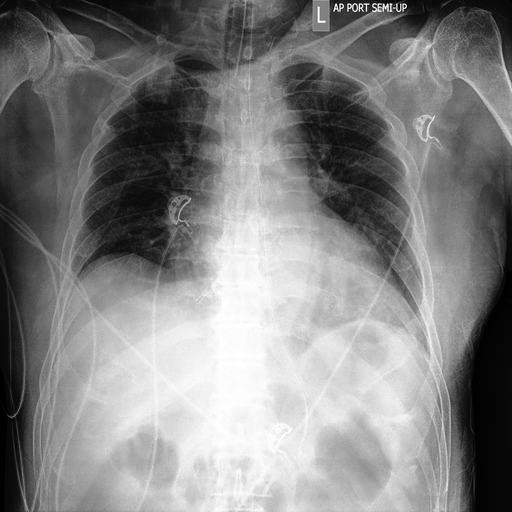

Image loaded and resized to: (512, 512)


In [35]:
from PIL import Image
from io import BytesIO
import gcsfs

# Path tothe google cloud storage  key
json_key_path = "/kaggle/input/optimal-carving-475915-u7-4c85df30bf2f/optimal-carving-475915-u7-4c85df30bf2f.json"

# Authenticating with google cloud storage
fs = gcsfs.GCSFileSystem(token=json_key_path)

# Image path
img_path = "gs://bernices-xray-dataset/PNG/train/patient00007/study2/view1_frontal.png"

# Open image from GCS
with fs.open(img_path, 'rb') as f:
    img = Image.open(BytesIO(f.read())).convert("RGB")

new_size = (512, 512)  
resized_img = img.resize(new_size, Image.LANCZOS)

# Display resized image
display(resized_img)
print(f"Image loaded and resized to: {new_size}")


In [20]:
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto"
).eval()

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [48]:
import os
from PIL import Image
from io import BytesIO

def get_cached_image(img_ref):
    """Simple image loading without multiprocessing issues"""
    try:
        fs_local = gcsfs.GCSFileSystem(
            token="/kaggle/input/optimal-carving-475915-u7-4c85df30bf2f/optimal-carving-475915-u7-4c85df30bf2f.json"
        )

        with fs_local.open(img_ref, "rb") as f:
            data = f.read()
        img = Image.open(BytesIO(data)).convert("RGB")
        return img
    except Exception as e:
        print(f"Failed to load image: {img_ref}")
        return Image.new("RGB", (224, 224), color='white')

# PERFORMING INFERENCE BEFORE FINETUNING

In this section, the dataset was passed through the base model, specifically the SmolVLM 500M, to assess its performance and determine if fine-tuning is necessary.

In [38]:
json_key_path = "/kaggle/input/optimal-carving-475915-u7-4c85df30bf2f/optimal-carving-475915-u7-4c85df30bf2f.json"
fs = gcsfs.GCSFileSystem(token=json_key_path)

row = data.sample(1, random_state=42).iloc[0]

img_path = str(row["current_image_path"]).replace("gs://bernices-xray-dataset/", "")
with fs.open(f"bernices-xray-dataset/{img_path}", "rb") as f:
    image = Image.open(BytesIO(f.read())).convert("RGB")
    image = image.resize((512, 512))

user_prompt = f"""
Generate the current chest X-ray report based on the following information.

Patient age: {row['current_age']} years  
Sex: {row['sex']}  
BMI: {row['current_recent_bmi']}  
View type: {row['current_frontal_lateral']}  

Prior report:
{row['prior_report']}

Generate a  current radiology report using the image and prior report.
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": user_prompt},
        ],
    }
]

# preparing model input
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors="pt").to(model.device)

# Generating the report
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=400, temperature=0.5, top_p=0.9)
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# Display report 
print("Generated Report:\n")
print(output_text.strip())
print("\nGround Truth:\n")
print(row["current_report"].strip() if isinstance(row["current_report"], str) else "N/A")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generated Report:

User:





Generate the current chest X-ray report based on the following information.

Patient age: 82.0 years  
Sex: Female  
BMI: 26.20192957067053  
View type: Frontal  

Prior report:
COMPARISON: 10-20-IMPRESSION: INITIAL 10/20/2012 CHEST RADIOGRAPH OBTAINED AT 1243 IS AP AND PORTABLE IN THE RECOVERY ROOM IN A SEMIERECT POSITION. THIS DEMONSTRATES TWO CHEST DRAINS AND SURGICAL SKIN STAPLES OVER THE LEFT HEMITHORAX. LUNG VOLUMES ARE DIMINISHED WITH A LEFT-SIDED PLEURAL EFFUSION. IT IS DIFFICULT TO ASSESS WHETHER THERE IS A PNEUMOTHORAX. THERE DOES APPEAR TO BE SOME SUBCUTANEOUS EMPHYSEMA. THERE APPEAR TO BE LOW VOLUMES WITH ASSOCIATED PULMONARY EDEMA. SUBSEQUENT CHEST RADIOGRAPH AT 1445 DEMONSTRATES INTERVAL REMOVAL OF THE TWO PREVIOUS CHEST TUBES WITH REPLACEMENT WITH A NEW CHEST TUBE ON THE LEFT. AGAIN, THERE IS NO DEFINITE PNEUMOTHORAX. THE LEFT PLEURAL EFFUSION IS SLIGHTLY DECREASED, ALTHOUGH THERE IS REDEMONSTRATION OF INCREASED OPACIFICATION OF THE LEFT RET

In [39]:
import gcsfs
from PIL import Image
from io import BytesIO
import torch
import random


json_key_path = "/kaggle/input/optimal-carving-475915-u7-4c85df30bf2f/optimal-carving-475915-u7-4c85df30bf2f.json"
fs = gcsfs.GCSFileSystem(token=json_key_path)

# random sample for inference
row = data.sample(1, random_state=42).iloc[0]

#loading image from Google Cloud Storage
img_path = str(row["current_image_path"]).replace("gs://bernices-xray-dataset/", "")
try:
    with fs.open(f"bernices-xray-dataset/{img_path}", "rb") as f:
        image = Image.open(BytesIO(f.read())).convert("RGB")
        image = image.resize((512, 512))
except Exception as e:
    raise RuntimeError(f" Error loading image from GCS: {img_path} — {e}")

# multimodal input
user_prompt = (
    f"Patient details:\n"
    f"- Age: {row['current_age']} years\n"
    f"- Sex: {row['sex']}\n"
    f"- BMI: {row['current_recent_bmi']}\n"
    f"- View Type: {row['current_frontal_lateral']}\n\n"
    f"Prior Report:\n{row['prior_report']}\n\n"
    "Based on the current chest X-ray image and prior findings, "
    "generate a full radiology report describing any new or persistent findings and impressions sections."
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": user_prompt},
        ],
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors="pt").to(model.device)

with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=350)
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Generated Report:\n")
print(output_text.strip())
print("\nGround Truth:\n")
print(row["current_report"].strip() if isinstance(row["current_report"], str) else "N/A")


Generated Report:

User:




Patient details:
- Age: 82.0 years
- Sex: Female
- BMI: 26.20192957067053
- View Type: Frontal

Prior Report:
COMPARISON: 10-20-IMPRESSION: INITIAL 10/20/2012 CHEST RADIOGRAPH OBTAINED AT 1243 IS AP AND PORTABLE IN THE RECOVERY ROOM IN A SEMIERECT POSITION. THIS DEMONSTRATES TWO CHEST DRAINS AND SURGICAL SKIN STAPLES OVER THE LEFT HEMITHORAX. LUNG VOLUMES ARE DIMINISHED WITH A LEFT-SIDED PLEURAL EFFUSION. IT IS DIFFICULT TO ASSESS WHETHER THERE IS A PNEUMOTHORAX. THERE DOES APPEAR TO BE SOME SUBCUTANEOUS EMPHYSEMA. THERE APPEAR TO BE LOW VOLUMES WITH ASSOCIATED PULMONARY EDEMA. SUBSEQUENT CHEST RADIOGRAPH AT 1445 DEMONSTRATES INTERVAL REMOVAL OF THE TWO PREVIOUS CHEST TUBES WITH REPLACEMENT WITH A NEW CHEST TUBE ON THE LEFT. AGAIN, THERE IS NO DEFINITE PNEUMOTHORAX. THE LEFT PLEURAL EFFUSION IS SLIGHTLY DECREASED, ALTHOUGH THERE IS REDEMONSTRATION OF INCREASED OPACIFICATION OF THE LEFT RETROCARDIAC REGION AND A SMALL PLEURAL EFFUSION. LOW LUNG VOLUMES PERSI

In [40]:
!pip install -q evaluate bert-score nltk rouge-score

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00


In [41]:
import evaluate
import nltk
nltk.download('punkt')

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [44]:
from tqdm import tqdm
import torch, gc

MAX_NEW_TOKENS = 350   
device = model.device

preds, refs = [], []
rows = eval_df.reset_index().to_dict("records")

for row in tqdm(rows, desc="Full inference (safe mode)"):
    try:
        img_path = str(row["current_image_path"]).replace("gs://bernices-xray-dataset/", "")
        with fs.open(f"bernices-xray-dataset/{img_path}", "rb") as f:
            image = Image.open(BytesIO(f.read())).convert("RGB").resize((512, 512))

        messages = [{"role":"user","content":[{"type":"image"},{"type":"text","text":user_prompt}]}]
        prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
        inputs = processor(text=prompt, images=[image], return_tensors="pt").to(device)

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)  
            generated = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        preds.append(generated)
        refs.append(row["current_report"].strip() if isinstance(row["current_report"], str) else "")

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("OOM encountered — clearing cache and retrying single sample with smaller max tokens.")
            torch.cuda.empty_cache(); gc.collect()
            try:
                with torch.no_grad():
                    generated_ids = model.generate(**inputs, max_new_tokens=100)
                    generated = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
                preds.append(generated)
                refs.append(row["current_report"].strip() if isinstance(row["current_report"], str) else "")
            except Exception as ex:
                print("Failed after retry:", ex)
                preds.append("") ; refs.append(row["current_report"].strip() if isinstance(row["current_report"], str) else "")
        else:
            print("Generation error:", e)
            preds.append("") ; refs.append(row["current_report"].strip() if isinstance(row["current_report"], str) else "")
    finally:
        del inputs, generated_ids
        torch.cuda.empty_cache()
        gc.collect()


Full inference (safe mode): 100%|██████████| 289/289 [1:16:54<00:00, 15.97s/it]


In [45]:
# calculating bleu
bleu_result = bleu.compute(predictions=preds, references=[[r] for r in refs])

#calculating rouge
rouge_result = rouge.compute(predictions=preds, references=refs)

# calculating BERTScore 
bertscore_result = bertscore.compute(predictions=preds, references=refs, lang="en")

print("Evaluation metrics on my data before finetuning")
print(f"BLEU: {bleu_result['bleu']*100:.2f}")
print(f"ROUGE-L: {rouge_result['rougeL']*100:.2f}")
print(f"BERTScore (F1): {sum(bertscore_result['f1'])/len(bertscore_result['f1']):.4f}")


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluation metrics on my data before finetuning
BLEU: 1.29
ROUGE-L: 8.26
BERTScore (F1): 0.8048


# CONCLUSION

From the inference, it is clear that the model is not really performing well, with 1.29% compared to the ground truth. 
Although the Bertscore is 0.8048, it doesn't have the clinical language and structure of a Chest X-ray radiology report.Hence, finetuning this vision language model will make it best for radiologists.
